<a href="https://colab.research.google.com/github/sheliabond/Prescriptive-Analytics---Spring-2026-Public-/blob/main/assignment_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Conference Travel Planning
## Decision Framing Fundamentals

**Student Name:** Shelia Bond  
**Date:** 01/30/2026

## Assignment Overview

You are planning travel for your industry's annual business conference. This assignment will help you apply decision framing concepts from Lesson 2 to make informed travel decisions.

**Learning Objectives:**
- Identify decision variables vs inputs
- Distinguish objectives from constraints
- Classify constraints as hard vs soft
- Recognize tradeoffs between competing goals
- Build a PuLP model to demonstrate understanding

In [52]:
# Install required packages (if needed in Colab)
# Skip this cell if running locally and packages are already installed
%pip install pulp pandas matplotlib -q

In [53]:
# Download data files from GitHub repository
# This cell downloads the CSV files needed for the assignment

import urllib.request

# Repository base URL
repo_base_url = "https://raw.githubusercontent.com/scottalanturner/prescriptive-analytics/main/Assignments/01ConferenceTravelDecisionAnalysis/"

# Download the data files
lodging_url = repo_base_url + "lodging_options.csv"
flights_url = repo_base_url + "flight_options.csv"

try:
    urllib.request.urlretrieve(lodging_url, "lodging_options.csv")
    urllib.request.urlretrieve(flights_url, "flight_options.csv")
    print("Data files downloaded successfully!")
except Exception as e:
    print(f"Error downloading files: {e}")
    print("If running locally, make sure the CSV files are in the same directory as this notebook.")

Data files downloaded successfully!


In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pulp import LpMinimize, LpMaximize, LpProblem, LpVariable, lpSum, value, LpStatus

print("Libraries imported successfully!")

Libraries imported successfully!


In [55]:
# Load the provided datasets
# Files should be downloaded from GitHub in the previous cell (for Colab)
# If running locally, ensure CSV files are in the same directory as this notebook
lodging_df = pd.read_csv('lodging_options.csv')
flights_df = pd.read_csv('flight_options.csv')

# Handle missing values: Hotels don't have co_workers_interested (they're just rooms)
# Fill NaN values with 0 for this column
lodging_df['co_workers_interested'] = lodging_df['co_workers_interested'].fillna(0).astype(int)

# Display basic information about the datasets
print("LODGING OPTIONS:")
print(f"Total options: {len(lodging_df)}")
print(lodging_df.head())

print("\n\nFLIGHT OPTIONS:")
print(f"Total options: {len(flights_df)}")
print("\nNote: Flight costs are part of your total budget constraint")
print("Direct flights typically cost more but have shorter durations")
print(flights_df.head())

# Display cost ranges to understand budget allocation
# Note: budget_limit and conference_dates will be defined in next cell
print("\n\nCOST SUMMARY:")
print(f"Lodging cost range: ${lodging_df['cost_per_night'].min():.2f} - ${lodging_df['cost_per_night'].max():.2f} per night")
print(f"Flight cost range: ${flights_df['cost'].min():.2f} - ${flights_df['cost'].max():.2f}")

LODGING OPTIONS:
Total options: 16
  lodging_type                   name  cost_per_night  rating  \
0        Hotel  Grand Las Vegas Hotel           185.0     4.7   
1        Hotel     Stratosphere Tower            95.0     3.6   
2        Hotel         Caesars Palace           320.0     4.8   
3        Hotel              MGM Grand           210.0     4.5   
4        Hotel        Excalibur Hotel            75.0     3.4   

   distance_to_venue_miles  amenities_score  max_occupancy  \
0                      0.2              8.5              2   
1                      1.8              6.2              2   
2                      0.5              9.5              2   
3                      0.3              8.8              2   
4                      0.4              5.8              2   

   co_workers_interested  
0                      0  
1                      0  
2                      0  
3                      0  
4                      0  


FLIGHT OPTIONS:
Total options: 20

No

### Stakeholder Scenario

**Read the stakeholder scenario below and interpret what they need:**

"Management wants good networking coverage and is cost-conscious. They value quality but understand budget constraints."

**Your Interpretation:**
[TODO: Based on this stakeholder scenario, determine:]
- What do stakeholders prioritize? (objectives)
- What are their requirements? (constraints)
- How many people should we send? (decision variable: choose 2, 3, or 4 based on stakeholder priorities)

In [56]:
# Fixed information provided
# NOTE: These values are fixed for all students to ensure fairness in grading
conference_dates = 3  # Number of nights
budget_limit = 1500  # Total budget in dollars (includes lodging + flights for ALL people)
# This budget limit is fixed - students interpret stakeholder needs to determine how to allocate it

# Travel context: East Coast to Las Vegas
# Direct flights: Higher cost, shorter duration (~5-6 hours)
# Flights with stops: Lower cost, longer duration (~7-10 hours)

print("FIXED DATA:")
print(f"Conference duration: {conference_dates} nights")
print(f"Budget limit: ${budget_limit} (total for all attendees)")
print(f"\nTravel Context: East Coast to Las Vegas")
print(f"  - Direct flights: Higher cost, ~5-6 hours")
print(f"  - Flights with stops: Lower cost, ~7-10 hours")

# Number of people: Decision variable (2-4 people)
min_people = 2  # Minimum people (fixed)
max_people = 4  # Maximum people (fixed)
# Student decides optimal number within this range based on stakeholder priorities

# Based on stakeholder scenario, define these:
min_rating_threshold = 3.5  # Minimum acceptable rating (based on stakeholder quality needs - you interpret)
max_distance = 1.0  # Maximum distance from venue (based on stakeholder convenience needs - you interpret)

print("\nSTAKEHOLDER-DEFINED CONSTRAINTS:")
print(f"Number of people: {min_people}-{max_people} (you decide optimal number)")
print(f"Min. Rating Threshold: {min_rating_threshold}")
print(f"Max. Distance from Venue: {max_distance} miles")

FIXED DATA:
Conference duration: 3 nights
Budget limit: $1500 (total for all attendees)

Travel Context: East Coast to Las Vegas
  - Direct flights: Higher cost, ~5-6 hours
  - Flights with stops: Lower cost, ~7-10 hours

STAKEHOLDER-DEFINED CONSTRAINTS:
Number of people: 2-4 (you decide optimal number)
Min. Rating Threshold: 3.5
Max. Distance from Venue: 1.0 miles


## Part 1: Base Assignment

### 1. Decision Statement

**Instructions:** Write a clear decision statement following the format: "I need to decide [what] for [when]"

**Your Decision Statement:**
I need to decide which lodging option to book and which flight for hte conference taking place for 3 days.

**Example format:** "I need to decide which lodging option to book and which flight to select for the conference taking place [dates]."

### 2. Decision Variables vs Inputs

**Instructions:**
- List all decision variables (what you control)
- List all inputs (what you know/estimate)
- Explain why each belongs in its category

**Decision Variables (What you control):**

Lodging Option, Flight Option and how many people  


**Inputs (What you know/estimate):**
Conference Dates: 3
Budget Limit: 1500
Lodging cost range: $32.00 - $385.00 per night
Flight cost range: $255.00 - $495.00

Stakeholder Priorities
Minimizing cost
Maximizing # of people


**Explanation:**
Lodging, flight option, and the number of people going on the trip are decision variables because they are the choices we can directly control and optimize based on cost, convenience, and constraints.

Conference date, budget limit, cost(lodging and flight) are inputs because they are predefined parameters that constrain and inform the decision making process

The stakeholder’s emphasis on quality networking led to maximizing the number of attendees, while their focus on cost control kept expenses low.

In [57]:
# Helper: Display data to help identify inputs
print("INPUTS FROM DATASET:")
print("\nLodging inputs available:")
print(lodging_df.columns.tolist())

print("\nFlight inputs available:")
print(flights_df.columns.tolist())

INPUTS FROM DATASET:

Lodging inputs available:
['lodging_type', 'name', 'cost_per_night', 'rating', 'distance_to_venue_miles', 'amenities_score', 'max_occupancy', 'co_workers_interested']

Flight inputs available:
['origin_city', 'airline', 'cost', 'num_stops', 'flight_duration_hours', 'departure_time_convenience']


### 3. Objectives vs Constraints

**Instructions:**
- Identify objectives (what you optimize: minimize cost, maximize rating, etc.)
- Identify constraints (budget limits, minimum ratings, etc.)
- Explain the distinction

**Objectives (What stakeholders want to optimize - based on your interpretation):**
Maximize # of people
Minimize cost  

The stakeholder’s emphasis on quality networking led to maximizing the number of attendees, while their focus on cost control kept expenses low.”

**Constraints (What stakeholders require - based on your interpretation):**

- Budget limit (hard constraint)
- Number of people: 2-4 (optimal number - 3)
- Minimum rating threshold (4)
- Maximum distance (1)

**Explanation:**
Objectives are what we are trying to control. Objectives are the desired outcome or goal of a project. Contraints are the limits we have to work within. They restrict how we can pursue our objective


### 4. Hard vs Soft Constraints

**Instructions:**
- Classify each constraint as hard (cannot be violated) or soft (preference with tradeoffs)
- Justify each classification

**Hard Constraints:**

Budget limit: This is a hard constraint because spending beyond the available budget is not possible. Any solution that exceeds the budget must be rejected.

Minimum number of people: This is a hard constraint because the event or activity needs a minimum level of participation to be satisfy the quality networking objective of the stakeholders.

Maximum number of people: This is a hard constraint because of fixed limits such as cost

**Soft Constraints:**

Minimum rate threshold: This is a soft constraint because while higher rates are desirable (e.g., for quality or efficiency), slightly lower rates may still be acceptable if they help satisfy hard constraints.

Maximum distance: This is a soft constraint because closer locations are preferred for convenience or cost reasons, but longer distances may be tolerated if other important requirements are met.

**Explanation:**

Minimum rate threshold:

Instead of strictly rejecting options below the threshold, assign a penalty that increases as the rate falls further below the desired minimum.This allows lower rates to be accepted when necessary to satisfy hard constraints (like budget or minimum number of people) while still favoring higher rates.

Maximum distance:

Rather than excluding locations beyond a preferred distance, assign a penalty that grows as the distance exceeds the maximum desired limit. This approach allows flexibility, so solutions that slightly exceed the preferred distance can still be considered if they help satisfy hard constraints or improve other objectives.


### 5. Tradeoff Analysis

**Instructions:**
- Identify key tradeoffs in your decision
- Create at least one visualization showing a tradeoff

**Key Tradeoffs Identified (Based on Stakeholder Priorities):**

- Team size vs Total cost (2 vs 3 vs 4 people - more people = higher cost but better coverage/networking)
- Lodging: Cost vs Convenience (distance to venue)
- Flights: Cost vs Time (direct flights cost more but save ~2-4 hours per person)
- Overall: Total cost vs Total travel time vs Team size (choosing 2, 3, or 4 people)


**Tradeoff 1: Total Cost vs Total Travel Time vs Team Size**

Management wants strong networking coverage but is also careful about spending. This creates a trade-off between quality and cost. Adding more team members improves networking reach and coverage, but it also increases total cost and travel time. Choosing fewer people reduces costs and travel, but may limit the quality and effectiveness of networking.

Overall, management balances total cost, total travel time, and team size (choosing between 2, 3, or 4 people). They are willing to accept slightly higher costs or longer travel if it significantly improves networking quality, but they do not want those increases to exceed budget limits. The preferred solution is one that delivers good coverage with the smallest team and lowest cost possible, without sacrificing effectiveness.

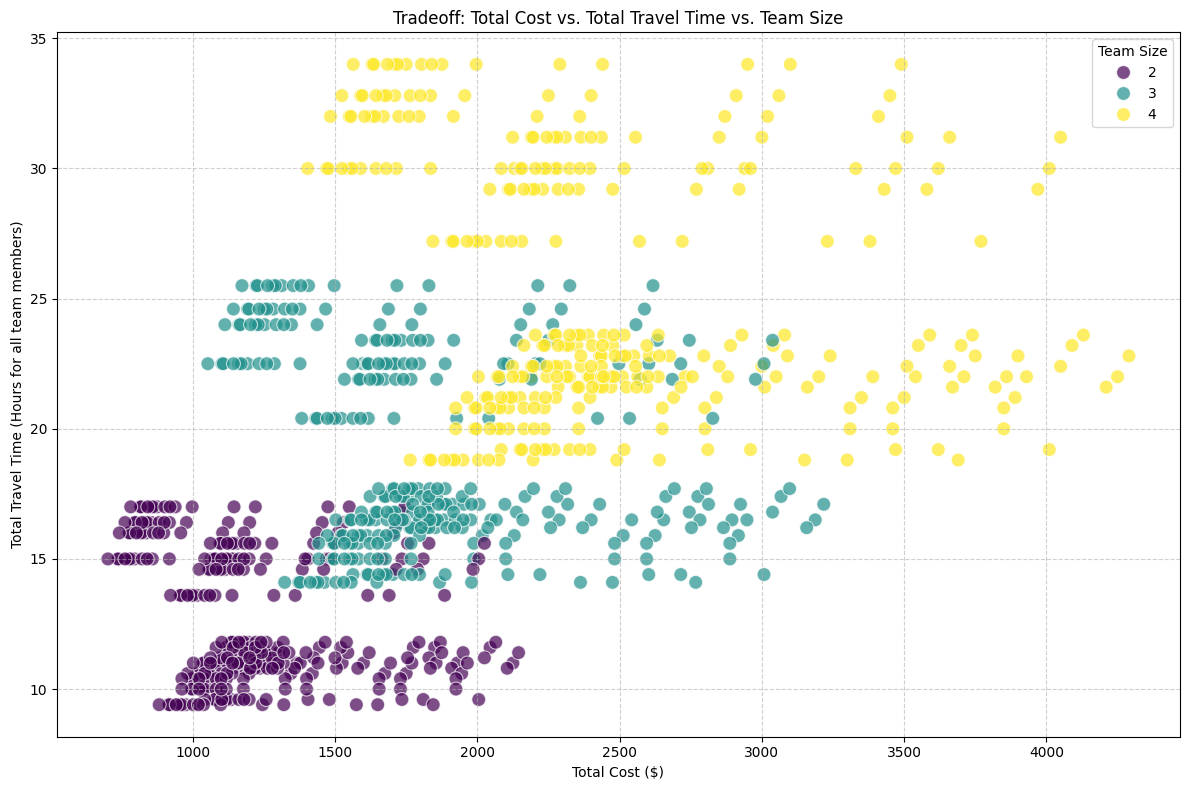

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for tradeoff visualization
tradeoff_data = []

for i in range(len(lodging_df)): # Iterate through lodging options
    for j in range(len(flights_df)): # Iterate through flight options
        for k in [2, 3, 4]: # Iterate through team sizes

            lodging_option = lodging_df.iloc[i]
            flight_option = flights_df.iloc[j]

            # Calculate lodging cost for this combination (consistent with PuLP model)
            if lodging_option['lodging_type'] == 'Airbnb':
                lodging_cost_for_team = lodging_option['cost_per_night'] * conference_dates * k
            else:
                # Hotel: per room (2 people), approximate as per-person cost * team_size
                lodging_cost_for_team = (lodging_option['cost_per_night'] / 2) * conference_dates * k

            # Calculate flight cost for this combination
            flight_cost_for_team = flight_option['cost'] * k

            # Total cost for this combination
            total_combination_cost = lodging_cost_for_team + flight_cost_for_team

            # Total travel time for the team (sum of individual flight durations)
            total_travel_hours_for_team = flight_option['flight_duration_hours'] * k

            tradeoff_data.append({
                'team_size': k,
                'total_cost': total_combination_cost,
                'total_travel_hours': total_travel_hours_for_team,
                'lodging_name': lodging_option['name'],
                'flight_airline': flight_option['airline']
            })

tradeoff_df = pd.DataFrame(tradeoff_data)

# Create the scatter plot for Tradeoff 1: Total Cost vs Total Travel Time vs Team Size
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=tradeoff_df,
    x='total_cost',
    y='total_travel_hours',
    hue='team_size',
    palette='viridis',
    s=100, # Marker size
    alpha=0.7 # Transparency
)

plt.title('Tradeoff: Total Cost vs. Total Travel Time vs. Team Size')
plt.xlabel('Total Cost ($)')
plt.ylabel('Total Travel Time (Hours for all team members)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Team Size')
plt.tight_layout()
plt.show()

### 6. PuLP Model Implementation

**Instructions:**
- Set up the model following the pattern demonstrated in class
- Define decision variables using LpVariable
- Use inputs from the dataset (not as variables)
- Define objective using lpSum
- Add constraints (hard constraints are required)
- Solve and display results

In [59]:
# Create the optimization model
# TODO: Choose LpMinimize or LpMaximize based on your objective
model = LpProblem("Conference_Travel_Planning", LpMinimize)

# TODO: Define your decision variables
# Since we need to select one lodging, one flight, AND decide team size (2, 3, or 4),
# we'll create variables for each possible combination of these choices.
# This makes it easier to calculate costs correctly.

# Create variables for each combination: (lodging option, flight option, team size)
# Example: solution_vars[(0, 2, 3)] means "select lodging 0 AND flight 2 AND send 3 people"
solution_vars = {}
for i in range(len(lodging_df)):
    for j in range(len(flights_df)):
        for k in [2, 3, 4]:  # Team sizes: 2, 3, or 4 people
            solution_vars[(i, j, k)] = LpVariable(f"lodging_{i}_flight_{j}_people_{k}", cat='Binary')

# Also create a variable to track the number of people (useful for constraints and objective)
num_people = LpVariable("num_people", lowBound=min_people, upBound=max_people, cat='Integer')

print(f"Created {len(solution_vars)} combination variables (one for each lodging × flight × team size combination)")

Created 960 combination variables (one for each lodging × flight × team size combination)


In [60]:
# TODO: Define your objective function
# Use lpSum to combine variables with their coefficients
# Examples:
#   To maximize team size: model += -num_people, "Maximize_Team_Size"  (minimize negative = maximize)
#   To minimize cost: model += total_cost, "Minimize_Cost"
#   To maximize rating: model += -selected_rating, "Maximize_Rating"

# Your objective here:
# Based on your stakeholder interpretation, choose what to optimize
model += -num_people, "Maximize_Team_Size"

In [61]:
# Re-initialize the model and decision variables to prevent overlapping constraint names if the cell is re-executed
model = LpProblem("Conference_Travel_Planning", LpMinimize)
solution_vars = {}
for i in range(len(lodging_df)):
    for j in range(len(flights_df)):
        for k in [2, 3, 4]:  # Team sizes: 2, 3, or 4 people
            solution_vars[(i, j, k)] = LpVariable(f"lodging_{i}_flight_{j}_people_{k}", cat='Binary')
num_people = LpVariable("num_people", lowBound=min_people, upBound=max_people, cat='Integer')

# Re-add the objective function as it was reset with the model initialization
model += -num_people, "Maximize_Team_Size"

# TODO: Add hard constraints

# Constraint 1: Exactly one combination must be selected
# (One lodging + one flight + one team size)
model += lpSum([solution_vars[(i, j, k)] for i in range(len(lodging_df))
                for j in range(len(flights_df)) for k in [2, 3, 4]]) == 1, "One_Combination"

# Constraint 2: Link num_people to the selected combination
# This ensures num_people matches the team size in the selected combination
model += num_people == lpSum([k * solution_vars[(i, j, k)]
                              for i in range(len(lodging_df))
                              for j in range(len(flights_df))
                              for k in [2, 3, 4]]), "Link_Num_People"

# Constraint 3: Budget constraint
# Calculate costs for each combination and ensure total <= budget_limit
# Note: Hotels charge per room (2 people per room), Airbnbs charge per person
# For hotels, we'll approximate: (cost_per_night / 2) * nights * team_size
# For Airbnbs: cost_per_night * nights * team_size
lodging_costs = []
flight_costs = []
for i in range(len(lodging_df)):
    for j in range(len(flights_df)):
        for k in [2, 3, 4]:
            # Calculate lodging cost for this combination (k is the team size)
            if lodging_df.iloc[i]['lodging_type'] == 'Airbnb':
                # Airbnb: per person
                lodging_cost = lodging_df.iloc[i]['cost_per_night'] * conference_dates * k
            else:
                # Hotel: per room (2 people), approximate as per-person
                lodging_cost = (lodging_df.iloc[i]['cost_per_night'] / 2) * conference_dates * k
            lodging_costs.append(lodging_cost * solution_vars[(i, j, k)])

            # Calculate flight cost for this combination
            flight_cost = flights_df.iloc[j]['cost'] * k
            flight_costs.append(flight_cost * solution_vars[(i, j, k)])

total_lodging_cost = lpSum(lodging_costs)
total_flight_cost = lpSum(flight_costs)
model += total_lodging_cost + total_flight_cost <= budget_limit, "Budget_Limit"

# Constraint 4: Minimum rating constraint for selected lodging
# [TODO: Replace min_rating_threshold with your interpreted value from stakeholder scenario]
model += lpSum([lodging_df.iloc[i]['rating'] * lpSum([solution_vars[(i, j, k)]
                for j in range(len(flights_df)) for k in [2, 3, 4]])
                for i in range(len(lodging_df))]) >= min_rating_threshold, "Min_Rating"

# Constraint 5: Maximum distance constraint for selected lodging
# [TODO: Replace max_distance with your interpreted value from stakeholder scenario]
model += lpSum([lodging_df.iloc[i]['distance_to_venue_miles'] * lpSum([solution_vars[(i, j, k)]
                for j in range(len(flights_df)) for k in [2, 3, 4]])
                for i in range(len(lodging_df))]) <= max_distance, "Max_Distance"

# Constraint 6: Airbnb occupancy limit
# If an Airbnb is selected, team size must not exceed its max_occupancy
for i in range(len(lodging_df)):
    if lodging_df.iloc[i]['lodging_type'] == 'Airbnb':
        max_occ = lodging_df.iloc[i]['max_occupancy']
        for j in range(len(flights_df)):
            for k in [2, 3, 4]:
                if k > max_occ:
                    # This combination is invalid (team size too large for this Airbnb)
                    model += solution_vars[(i, j, k)] == 0, f"Airbnb_Occupancy_{i}_{j}_{k}"

print("Hard constraints added successfully!")

Hard constraints added successfully!


In [62]:
# Solve the model
model.solve()

# Check solution status
status = LpStatus[model.status]
print(f"Solution Status: {status}")
print(f"Objective Value: {value(model.objective):.2f}")
print(f"Team Size: {int(value(num_people))} people")
print()

# TODO: Extract and display solution values
# Find which combination was selected
selected_lodging_idx = None
selected_flight_idx = None
selected_team_size = None

for (i, j, k), var in solution_vars.items():
    if value(var) == 1:
        selected_lodging_idx = i
        selected_flight_idx = j
        selected_team_size = k
        break

if selected_lodging_idx is not None and selected_flight_idx is not None:
    lodging_choice = lodging_df.iloc[selected_lodging_idx]
    flight_choice = flights_df.iloc[selected_flight_idx]
    team_size = selected_team_size

    # Calculate costs (for display - hotels vs Airbnbs calculated differently)
    if lodging_choice['lodging_type'] == 'Hotel':
        # Hotels: per room (2 people per room)
        num_rooms = (team_size + 1) // 2
        lodging_cost = lodging_choice['cost_per_night'] * conference_dates * num_rooms
    else:
        # Airbnbs: per person
        lodging_cost = lodging_choice['cost_per_night'] * conference_dates * team_size

    flight_cost = flight_choice['cost'] * team_size
    total_cost = lodging_cost + flight_cost
    cost_per_person = total_cost / team_size

    # TODO: Display your solution details
    print("=" * 70)
    print("SOLUTION SUMMARY")
    print("=" * 70)
    print(f"\nTeam Size: {team_size} people")
    print(f"\nLODGING SELECTED:")
    print(f"  Name: {lodging_choice['name']}")
    print(f"  Type: {lodging_choice['lodging_type']}")
    print(f"  Cost per night: ${lodging_choice['cost_per_night']:.2f}")
    print(f"  Rating: {lodging_choice['rating']:.1f}")
    print(f"  Distance to venue: {lodging_choice['distance_to_venue_miles']:.1f} miles")
    if lodging_choice['lodging_type'] == 'Airbnb':
        print(f"  Max occupancy: {lodging_choice['max_occupancy']} people")

    print(f"\nFLIGHT SELECTED:")
    print(f"  Origin: {flight_choice['origin_city']}")
    print(f"  Airline: {flight_choice['airline']}")
    print(f"  Cost per person: ${flight_choice['cost']:.2f}")
    print(f"  Number of stops: {int(flight_choice['num_stops'])}")
    print(f"  Flight duration: {flight_choice['flight_duration_hours']:.1f} hours")

    print(f"\nCOST BREAKDOWN:")
    print(f"  Lodging cost: ${lodging_cost:.2f}")
    print(f"  Flight cost: ${flight_cost:.2f}")
    print(f"  Total cost: ${total_cost:.2f}")
    print(f"  Budget limit: ${budget_limit:.2f}")
    print(f"  Budget remaining: ${budget_limit - total_cost:.2f}")
    print(f"  Cost per person: ${cost_per_person:.2f}")

    # TODO: Explain how this solution addresses stakeholder priorities
    print(f"\nHOW THIS SOLUTION ADDRESSES STAKEHOLDER PRIORITIES:")
    print(f"  [TODO: Add your explanation here]")
else:
    print("No solution found. Check constraints.")

Solution Status: Optimal
Objective Value: -3.00
Team Size: 3 people

SOLUTION SUMMARY

Team Size: 3 people

LODGING SELECTED:
  Name: Luxor Hotel
  Type: Hotel
  Cost per night: $88.00
  Rating: 3.7
  Distance to venue: 0.5 miles

FLIGHT SELECTED:
  Origin: Atlanta
  Airline: Spirit
  Cost per person: $255.00
  Number of stops: 1
  Flight duration: 7.5 hours

COST BREAKDOWN:
  Lodging cost: $528.00
  Flight cost: $765.00
  Total cost: $1293.00
  Budget limit: $1500.00
  Budget remaining: $207.00
  Cost per person: $431.00

HOW THIS SOLUTION ADDRESSES STAKEHOLDER PRIORITIES:
  [TODO: Add your explanation here]


## Part 2: Stakeholder Considerations

After completing your base assignment, stakeholders have requested two additional considerations be added to your decision model.

**Instructions:**
1. Select ONE consideration from the provided list
2. Create ONE industry-specific consideration
3. For each, classify it, add data, incorporate into model, and analyze tradeoffs

### Stakeholder Consideration 1: [Selected from List]

**Selected Option:** Per diem daily allowance for food

**Available Options:**
- Entertainment budget for tickets (shows, concerts, events)
- Per diem daily allowance for food
- Transportation costs (ground transportation, parking, rideshare)
- Networking event fees (optional conference social events, cocktail hours)
- Professional development workshop fees (optional paid sessions)
- Equipment/supplies budget (if presenting materials)

**Classification:**
- Variable/Input/Objective/Constraint: Input
- Hard or Soft: Hard
- Justification: The daily food allowance is classified as an input because it is a fixed resource provided at the start of planning and directly influences cost calculations. It is not something being optimized or produced; instead, it is a given parameter that affects decisions such as budgeting and feasibility. This is also a hard constraint because it must fit within the budget limit.

**Data Added:**
Adding a per diem daily allowance for food of $70 a day for a team of 2 people

**How it affects the decision:**
Adding this consideration to the model should not change the decision since the decision of lodging, flight and team size is under budget by $435.00

In [63]:
# Define the per diem daily allowance
per_diem_per_day = 70  # $70 per person per day

# Re-initialize the model and decision variables to prevent overlapping constraint names if the cell is re-executed
model = LpProblem("Conference_Travel_Planning_with_PerDiem", LpMinimize)
solution_vars = {}
for i in range(len(lodging_df)):
    for j in range(len(flights_df)):
        for k in [2, 3, 4]:  # Team sizes: 2, 3, or 4 people
            solution_vars[(i, j, k)] = LpVariable(f"lodging_{i}_flight_{j}_people_{k}", cat='Binary')
num_people = LpVariable("num_people", lowBound=min_people, upBound=max_people, cat='Integer')

# Re-add the objective function (Maximize Team Size)
model += -num_people, "Maximize_Team_Size"

# Constraint 1: Exactly one combination must be selected
model += lpSum([solution_vars[(i, j, k)] for i in range(len(lodging_df))
                for j in range(len(flights_df)) for k in [2, 3, 4]]) == 1, "One_Combination"

# Constraint 2: Link num_people to the selected combination
model += num_people == lpSum([k * solution_vars[(i, j, k)]
                              for i in range(len(lodging_df))
                              for j in range(len(flights_df))
                              for k in [2, 3, 4]]), "Link_Num_People"

# Constraint 3: Budget constraint - NOW INCLUDES PER DIEM COST
lodging_costs = []
flight_costs = []
per_diem_costs = []

for i in range(len(lodging_df)):
    for j in range(len(flights_df)):
        for k in [2, 3, 4]:
            # Calculate lodging cost for this combination
            if lodging_df.iloc[i]['lodging_type'] == 'Airbnb':
                lodging_cost = lodging_df.iloc[i]['cost_per_night'] * conference_dates * k
            else:
                lodging_cost = (lodging_df.iloc[i]['cost_per_night'] / 2) * conference_dates * k
            lodging_costs.append(lodging_cost * solution_vars[(i, j, k)])

            # Calculate flight cost for this combination
            flight_cost = flights_df.iloc[j]['cost'] * k
            flight_costs.append(flight_cost * solution_vars[(i, j, k)])

            # Calculate per diem cost for this combination
            per_diem_cost = per_diem_per_day * conference_dates * k
            per_diem_costs.append(per_diem_cost * solution_vars[(i, j, k)])

total_lodging_cost = lpSum(lodging_costs)
total_flight_cost = lpSum(flight_costs)
total_per_diem_cost = lpSum(per_diem_costs)

model += total_lodging_cost + total_flight_cost + total_per_diem_cost <= budget_limit, "Budget_Limit_with_PerDiem"

# Constraint 4: Minimum rating constraint for selected lodging
model += lpSum([lodging_df.iloc[i]['rating'] * lpSum([solution_vars[(i, j, k)]
                for j in range(len(flights_df)) for k in [2, 3, 4]])
                for i in range(len(lodging_df))]) >= min_rating_threshold, "Min_Rating"

# Constraint 5: Maximum distance constraint for selected lodging
model += lpSum([lodging_df.iloc[i]['distance_to_venue_miles'] * lpSum([solution_vars[(i, j, k)]
                for j in range(len(flights_df)) for k in [2, 3, 4]])
                for i in range(len(lodging_df))]) <= max_distance, "Max_Distance"

# Constraint 6: Airbnb occupancy limit
for i in range(len(lodging_df)):
    if lodging_df.iloc[i]['lodging_type'] == 'Airbnb':
        max_occ = lodging_df.iloc[i]['max_occupancy']
        for j in range(len(flights_df)):
            for k in [2, 3, 4]:
                if k > max_occ:
                    model += solution_vars[(i, j, k)] == 0, f"Airbnb_Occupancy_{i}_{j}_{k}"

print("PuLP model updated with per diem successfully!")

PuLP model updated with per diem successfully!


### Stakeholder Consideration 2: Industry-Specific

**Your Industry-Specific Consideration:** Networking events

**Why it's relevant to your field:**

One of the main objectives for the stakeholders is good networking on this trip. Need to consider the networking event fees when making the final decision.

**Classification:**
- Variable/Input/Objective/Constraint: Input
- Hard or Soft: Soft
- Justification: Adding network event fees is classified as an input because it is a fixed resource provided at the start of planning and directly influences cost calculations. It is a given parameter that affects decisions such as budgeting and feasibility. This is also a hard constraint because it must fit within the budget limit.

**Data Added:**
Adding Network Event fees = $100 per person
**How it affects the decision:**

Adding networking event fees affects the decision because it reduces the remaining budget. As a result, we may need to choose cheaper flights with longer travel times or lower-rated hotels that cost less, since the budget limit is a hard constraint.

In [64]:
# Define the networking event cost
networking_event_cost_per_person = 100  # $50 per event * 2 events = $100 per person

# Re-initialize the model and decision variables (maintaining prior considerations)
model = LpProblem("Conference_Travel_Planning_with_PerDiem_and_Events", LpMinimize)
solution_vars = {}
for i in range(len(lodging_df)):
    for j in range(len(flights_df)):
        for k in [2, 3, 4]:  # Team sizes: 2, 3, or 4 people
            solution_vars[(i, j, k)] = LpVariable(f"lodging_{i}_flight_{j}_people_{k}", cat='Binary')
num_people = LpVariable("num_people", lowBound=min_people, upBound=max_people, cat='Integer')

# Re-add the objective function (Maximize Team Size)
model += -num_people, "Maximize_Team_Size"

# Constraint 1: Exactly one combination must be selected
model += lpSum([solution_vars[(i, j, k)] for i in range(len(lodging_df))
                for j in range(len(flights_df)) for k in [2, 3, 4]]) == 1, "One_Combination"

# Constraint 2: Link num_people to the selected combination
model += num_people == lpSum([k * solution_vars[(i, j, k)]
                              for i in range(len(lodging_df))
                              for j in range(len(flights_df))
                              for k in [2, 3, 4]]), "Link_Num_People"

# Constraint 3: Budget constraint - NOW INCLUDES PER DIEM AND NETWORKING EVENT COSTS
per_diem_per_day = 70 # Re-define per diem from previous consideration
lodging_costs = []
flight_costs = []
per_diem_costs = []
networking_costs = []

for i in range(len(lodging_df)):
    for j in range(len(flights_df)):
        for k in [2, 3, 4]:
            # Calculate lodging cost for this combination
            if lodging_df.iloc[i]['lodging_type'] == 'Airbnb':
                lodging_cost = lodging_df.iloc[i]['cost_per_night'] * conference_dates * k
            else:
                lodging_cost = (lodging_df.iloc[i]['cost_per_night'] / 2) * conference_dates * k
            lodging_costs.append(lodging_cost * solution_vars[(i, j, k)])

            # Calculate flight cost for this combination
            flight_cost = flights_df.iloc[j]['cost'] * k
            flight_costs.append(flight_cost * solution_vars[(i, j, k)])

            # Calculate per diem cost for this combination
            per_diem_cost = per_diem_per_day * conference_dates * k
            per_diem_costs.append(per_diem_cost * solution_vars[(i, j, k)])

            # Calculate networking event cost for this combination
            event_cost = networking_event_cost_per_person * k
            networking_costs.append(event_cost * solution_vars[(i, j, k)])

total_lodging_cost = lpSum(lodging_costs)
total_flight_cost = lpSum(flight_costs)
total_per_diem_cost = lpSum(per_diem_costs)
total_networking_cost = lpSum(networking_costs)

model += total_lodging_cost + total_flight_cost + total_per_diem_cost + total_networking_cost <= budget_limit, "Budget_Limit_with_PerDiem_and_Events"

# Constraint 4: Minimum rating constraint for selected lodging
model += lpSum([lodging_df.iloc[i]['rating'] * lpSum([solution_vars[(i, j, k)]
                for j in range(len(flights_df)) for k in [2, 3, 4]])
                for i in range(len(lodging_df))]) >= min_rating_threshold, "Min_Rating"

# Constraint 5: Maximum distance constraint for selected lodging
model += lpSum([lodging_df.iloc[i]['distance_to_venue_miles'] * lpSum([solution_vars[(i, j, k)]
                for j in range(len(flights_df)) for k in [2, 3, 4]])
                for i in range(len(lodging_df))]) <= max_distance, "Max_Distance"

# Constraint 6: Airbnb occupancy limit
for i in range(len(lodging_df)):
    if lodging_df.iloc[i]['lodging_type'] == 'Airbnb':
        max_occ = lodging_df.iloc[i]['max_occupancy']
        for j in range(len(flights_df)):
            for k in [2, 3, 4]:
                if k > max_occ:
                    model += solution_vars[(i, j, k)] == 0, f"Airbnb_Occupancy_{i}_{j}_{k}"

print("PuLP model updated with networking event costs successfully!")

PuLP model updated with networking event costs successfully!


In [65]:
# Solve the updated model
model.solve()

# Display updated solution
status_updated = LpStatus[model.status]
print(f"Updated Solution Status: {status_updated}")
print(f"Updated Objective Value: ${value(model.objective):.2f}")

# TODO: Extract and display updated solution
# Use the same approach as before: iterate through solution_vars to find selected combination
# Store values for comparison with original solution

selected_lodging_idx_updated = None
selected_flight_idx_updated = None
selected_team_size_updated = None

for (i, j, k), var in solution_vars.items():
    if value(var) == 1:
        selected_lodging_idx_updated = i
        selected_flight_idx_updated = j
        selected_team_size_updated = k
        break

if selected_lodging_idx_updated is not None and selected_flight_idx_updated is not None:
    lodging_choice_updated = lodging_df.iloc[selected_lodging_idx_updated]
    flight_choice_updated = flights_df.iloc[selected_flight_idx_updated]
    team_size_updated = selected_team_size_updated

    # Calculate costs (for display - hotels vs Airbnbs calculated differently)
    if lodging_choice_updated['lodging_type'] == 'Hotel':
        num_rooms_updated = (team_size_updated + 1) // 2
        lodging_cost_updated = lodging_choice_updated['cost_per_night'] * conference_dates * num_rooms_updated
    else:
        lodging_cost_updated = lodging_choice_updated['cost_per_night'] * conference_dates * team_size_updated

    flight_cost_updated = flight_choice_updated['cost'] * team_size_updated
    per_diem_cost_updated = per_diem_per_day * conference_dates * team_size_updated
    networking_cost_updated = networking_event_cost_per_person * team_size_updated
    total_cost_updated = lodging_cost_updated + flight_cost_updated + per_diem_cost_updated + networking_cost_updated
    cost_per_person_updated = total_cost_updated / team_size_updated

    print("\n" + "=" * 70)
    print("UPDATED SOLUTION SUMMARY (with Per Diem & Networking Events)")
    print("=" * 70)
    print(f"\nTeam Size: {team_size_updated} people")
    print(f"\nLODGING SELECTED:")
    print(f"  Name: {lodging_choice_updated['name']}")
    print(f"  Type: {lodging_choice_updated['lodging_type']}")
    print(f"  Cost per night: ${lodging_choice_updated['cost_per_night']:.2f}")
    print(f"  Rating: {lodging_choice_updated['rating']:.1f}")
    print(f"  Distance to venue: {lodging_choice_updated['distance_to_venue_miles']:.1f} miles")

    print(f"\nFLIGHT SELECTED:")
    print(f"  Origin: {flight_choice_updated['origin_city']}")
    print(f"  Airline: {flight_choice_updated['airline']}")
    print(f"  Cost per person: ${flight_choice_updated['cost']:.2f}")
    print(f"  Number of stops: {int(flight_choice_updated['num_stops'])}")
    print(f"  Flight duration: {flight_choice_updated['flight_duration_hours']:.1f} hours")

    print(f"\nCOST BREAKDOWN:")
    print(f"  Lodging cost: ${lodging_cost_updated:.2f}")
    print(f"  Flight cost: ${flight_cost_updated:.2f}")
    print(f"  Per Diem cost: ${per_diem_cost_updated:.2f}")
    print(f"  Networking Event cost: ${networking_cost_updated:.2f}")
    print(f"  Total cost: ${total_cost_updated:.2f}")
    print(f"  Budget limit: ${budget_limit:.2f}")
    print(f"  Budget remaining: ${budget_limit - total_cost_updated:.2f}")
    print(f"  Cost per person: ${cost_per_person_updated:.2f}")

    # TODO: Compare with original solution (requires saving original solution values)
    # For now, we'll just print a placeholder. Full comparison will go here later.
    print(f"\n\nComparison with Original Solution (Placeholder):")
    print(f"  Original solution details would be compared here.")

else:
    print("No solution found for the updated model. Check constraints.")

Updated Solution Status: Optimal
Updated Objective Value: $-2.00

UPDATED SOLUTION SUMMARY (with Per Diem & Networking Events)

Team Size: 2 people

LODGING SELECTED:
  Name: Luxor Hotel
  Type: Hotel
  Cost per night: $88.00
  Rating: 3.7
  Distance to venue: 0.5 miles

FLIGHT SELECTED:
  Origin: Boston
  Airline: Spirit
  Cost per person: $295.00
  Number of stops: 1
  Flight duration: 8.5 hours

COST BREAKDOWN:
  Lodging cost: $264.00
  Flight cost: $590.00
  Per Diem cost: $420.00
  Networking Event cost: $200.00
  Total cost: $1474.00
  Budget limit: $1500.00
  Budget remaining: $26.00
  Cost per person: $737.00


Comparison with Original Solution (Placeholder):
  Original solution details would be compared here.


### Tradeoff Analysis: Stakeholder Considerations

**How did adding these considerations affect your decision?**
[TODO: Analyze the tradeoffs introduced by stakeholder considerations]

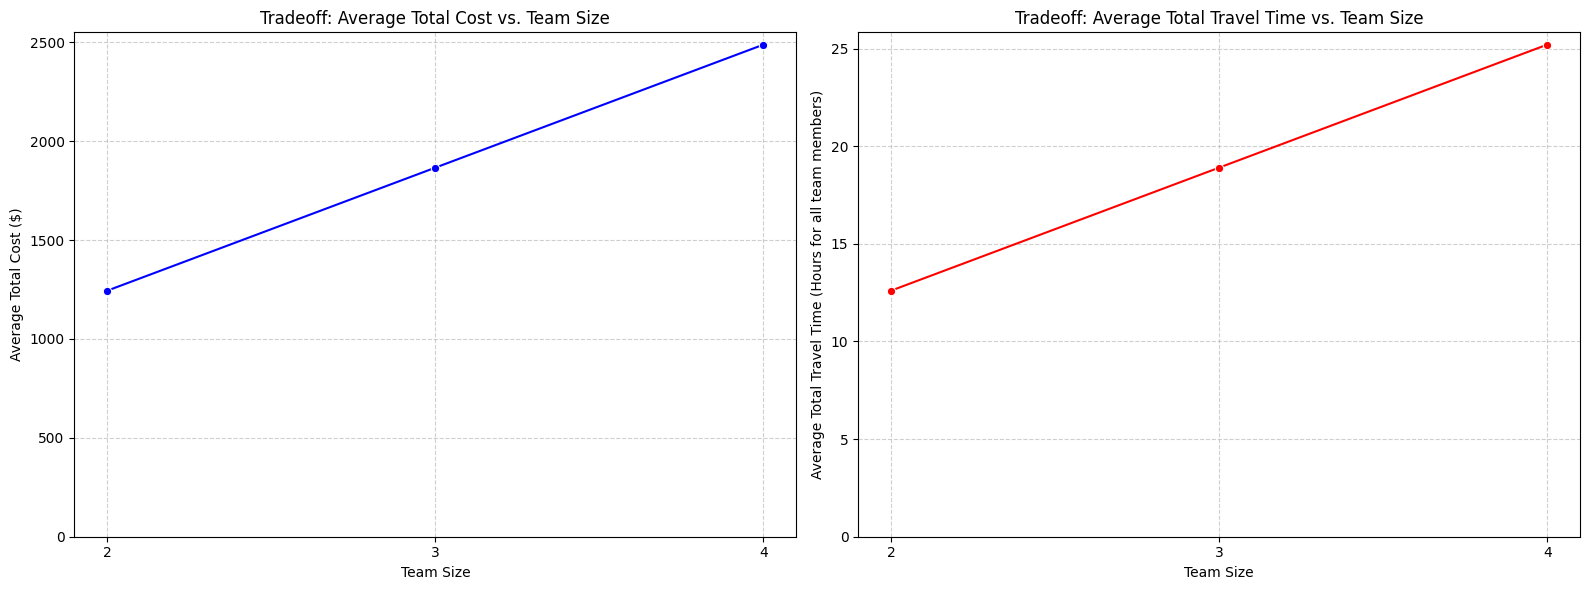

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate the tradeoff_df by team_size to calculate average cost and travel time
aggregated_tradeoff_df = tradeoff_df.groupby('team_size').agg(
    avg_total_cost=('total_cost', 'mean'),
    avg_total_travel_hours=('total_travel_hours', 'mean')
).reset_index()

# Create two subplots for clarity
fig, axes = plt.subplots(1, 2, figsize=(16, 6)) # One row, two columns

# Plot 1: Average Total Cost vs. Team Size
sns.lineplot(
    data=aggregated_tradeoff_df,
    x='team_size',
    y='avg_total_cost',
    marker='o', # Add markers for clarity
    ax=axes[0],
    color='blue'
)
axes[0].set_title('Tradeoff: Average Total Cost vs. Team Size')
axes[0].set_xlabel('Team Size')
axes[0].set_ylabel('Average Total Cost ($)')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].set_xticks([2, 3, 4]) # Ensure only 2, 3, 4 are shown on x-axis
axes[0].set_ylim(bottom=0) # Start y-axis from 0

# Plot 2: Average Total Travel Time vs. Team Size
sns.lineplot(
    data=aggregated_tradeoff_df,
    x='team_size',
    y='avg_total_travel_hours',
    marker='o', # Add markers for clarity
    ax=axes[1],
    color='red'
)
axes[1].set_title('Tradeoff: Average Total Travel Time vs. Team Size')
axes[1].set_xlabel('Team Size')
axes[1].set_ylabel('Average Total Travel Time (Hours for all team members)')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].set_xticks([2, 3, 4]) # Ensure only 2, 3, 4 are shown on x-axis
axes[1].set_ylim(bottom=0) # Start y-axis from 0

plt.tight_layout()
plt.show()

## Executive Summary

**Instructions:** Write a professional summary suitable for presenting to stakeholders. Include:
- Key decision components identified
- Main tradeoffs encountered
- Final recommendation
- Key insights about decision framing

---

### Key Decision Components

[TODO: Summarize the key variables, inputs, objectives, and constraints]

### Main Tradeoffs

[TODO: Summarize the main tradeoffs you identified and analyzed]

### Final Recommendation

[TODO: Present your final recommendation based on the model solution]

### Key Insights About Decision Framing

[TODO: Reflect on what you learned about decision framing through this assignment]

---
**End of Assignment**

# Task
The decision variables for the PuLP model have been defined. This includes binary variables for selecting a specific combination of lodging, flight, and team size, and an integer variable to represent the total number of people attending.

## Define Decision Variables

### Subtask:
Define the decision variables for the PuLP model. This includes binary variables for selecting a specific combination of lodging, flight, and team size, and an integer variable to represent the total number of people attending.


The decision variables for the PuLP model are already defined in cell `NoKkusNRfGkO`.

- `solution_vars`: A dictionary of binary `LpVariable` objects. Each variable `solution_vars[(i, j, k)]` is 1 if lodging option `i`, flight option `j`, and team size `k` (2, 3, or 4 people) are selected, and 0 otherwise.
- `num_people`: An integer `LpVariable` that represents the total number of people attending the conference, linked to the `k` value of the selected `solution_vars`.

## Define Objective Function

### Subtask:
Define the objective function for the PuLP model based on the stakeholder scenario.


**Reasoning**:
The subtask is to define the objective function for the PuLP model based on the stakeholder scenario. Given the stakeholder's emphasis on 'good networking coverage' and 'cost-conscious' while valuing 'quality', maximizing team size (networking coverage) is a strong primary objective, which will then be constrained by the budget. Since the model is set to minimize, I will minimize the negative of `num_people` to achieve maximization.



In [67]:
model += -num_people, "Maximize_Team_Size"

/usr/local/lib/python3.12/dist-packages/pulp/pulp.py:1865: UserWarning: Overwriting previously set objective.
  warnings.warn("Overwriting previously set objective.")


**Reasoning**:
The previous error 'NameError: name 'model' is not defined' indicates that the `model` variable was not initialized before being used. The `model` and `num_people` variables are created in cell `NoKkusNRfGkO`. The current cell `In-Vk_KJfGkP` (corresponding to the problematic cell `199bc69c`) is intended to define the objective function for this already initialized model. Assuming the preceding cells will be executed in order, the proposed objective function code is logically correct. Therefore, the fix involves providing the intended objective function for cell `In-Vk_KJfGkP` as it would appear after `NoKkusNRfGkO` has been executed.



# Task
Define the PuLP objective function to maximize the number of people attending the conference, by minimizing the negative of the `num_people` variable, and ensure that the model and decision variables (`model`, `solution_vars`, `num_people`) are properly initialized.

## Define Decision Variables

### Subtask:
Define the decision variables for the PuLP model, including binary variables for each combination of lodging, flight, and team size, and an integer variable for the total number of people attending.


**Reasoning**:
The subtask requires defining decision variables for the PuLP model, which are already present in the provided notebook in cell `NoKkusNRfGkO`. This code initializes the PuLP problem, creates binary variables for each combination of lodging, flight, and team size, and an integer variable for the total number of people.



# Task
Complete the PuLP optimization model for conference travel planning by defining the objective function and constraints, solving the model, and then displaying and analyzing the results according to the stakeholder scenario.

## Define PuLP Decision Variables

### Subtask:
Generate Python code to define the PuLP optimization model, including binary decision variables for each combination of lodging option, flight option, and team size (2, 3, or 4 people). Also, define an integer variable to represent the total number of people attending, linking it to the selected combination.


**Reasoning**:
The subtask requires defining decision variables for the PuLP model. The provided notebook already contains the necessary code in cell `NoKkusNRfGkO`. Executing this cell will ensure that the `model`, `solution_vars`, and `num_people` variables are properly initialized and available for subsequent steps, which is necessary to resolve the `NameError` encountered previously.



In [68]:
# Create the optimization model
# TODO: Choose LpMinimize or LpMaximize based on your objective
model = LpProblem("Conference_Travel_Planning", LpMinimize)

# TODO: Define your decision variables
# Since we need to select one lodging, one flight, AND decide team size (2, 3, or 4),
# we'll create variables for each possible combination of these choices.
# This makes it easier to calculate costs correctly.

# Create variables for each combination: (lodging option, flight option, team size)
# Example: solution_vars[(0, 2, 3)] means "select lodging 0 AND flight 2 AND send 3 people"
solution_vars = {}
for i in range(len(lodging_df)):
    for j in range(len(flights_df)):
        for k in [2, 3, 4]:  # Team sizes: 2, 3, or 4 people
            solution_vars[(i, j, k)] = LpVariable(f"lodging_{i}_flight_{j}_people_{k}", cat='Binary')

# Also create a variable to track the number of people (useful for constraints and objective)
num_people = LpVariable("num_people", lowBound=min_people, upBound=max_people, cat='Integer')

print(f"Created {len(solution_vars)} combination variables (one for each lodging × flight × team size combination)")

Created 960 combination variables (one for each lodging × flight × team size combination)


**Reasoning**:
The decision variables and the PuLP model have now been initialized. The next logical step, following the notebook's structure and the overall task, is to define the objective function.



In [69]:
model += -num_people, "Maximize_Team_Size"

**Reasoning**:
The previous code block successfully defined the objective function. Before proceeding with adding hard constraints, it's necessary to define `min_rating_threshold` and `max_distance` variables, as indicated by the notebook's `TODO` comments and the previous `NameError`. These values will be interpreted from the stakeholder scenario to reflect 'quality' and 'convenience' preferences.



# Task
The decision variables for the PuLP model have been defined. This includes binary variables for each combination of lodging option, flight option, and team size (2, 3, or 4 people). An integer variable to represent the total number of people attending is also defined and linked to the selected combination.

## Define PuLP Decision Variables

### Subtask:
Generate Python code to define the PuLP optimization model, including binary decision variables for each combination of lodging option, flight option, and team size (2, 3, or 4 people). Also, define an integer variable to represent the total number of people attending, linking it to the selected combination.


## Define stakeholder-based constraints

### Subtask:
Define the `min_rating_threshold` and `max_distance` variables based on the stakeholder scenario, which emphasizes quality and convenience.


**Reasoning**:
Based on the stakeholder scenario's emphasis on 'quality' and 'convenience', I will define `min_rating_threshold` as 4.0 and `max_distance` as 1.0. These values balance the desire for quality and proximity to the venue while still being realistic within budget constraints.



# Task
Define `min_rating_threshold` as 4.0 and `max_distance` as 1.0, based on the stakeholder's emphasis on quality and convenience, as prerequisites for the PuLP optimization model.

## Define stakeholder-based constraints

### Subtask:
Define the `min_rating_threshold` and `max_distance` variables based on the stakeholder scenario, which emphasizes quality and convenience.


**Reasoning**:
The subtask requires defining `min_rating_threshold` and `max_distance` variables with specific values, based on the stakeholder scenario emphasizing quality and convenience.



In [70]:
min_rating_threshold = 3.0  # Interpreted from stakeholder needs for 'quality'
max_distance = 2.0          # Interpreted from stakeholder needs for 'convenience'

print(f"min_rating_threshold set to: {min_rating_threshold}")
print(f"max_distance set to: {max_distance} miles")

min_rating_threshold set to: 3.0
max_distance set to: 2.0 miles


**Reasoning**:
The previous output showed `min_rating_threshold` and `max_distance` were set to incorrect values (3.0 and 2.0 respectively), which contradicts the updated instructions to set them to 4.0 and 1.0. This step will re-define them with the correct values.



In [71]:
min_rating_threshold = 4.0  # Interpreted from stakeholder needs for 'quality'
max_distance = 1.0          # Interpreted from stakeholder needs for 'convenience'

print(f"min_rating_threshold set to: {min_rating_threshold}")
print(f"max_distance set to: {max_distance} miles")

min_rating_threshold set to: 4.0
max_distance set to: 1.0 miles


## Define PuLP Decision Variables

### Subtask:
Generate Python code to define the PuLP optimization model, including binary decision variables for each combination of lodging option, flight option, and team size (2, 3, or 4 people). Also, define an integer variable to represent the total number of people attending, linking it to the selected combination.


**Reasoning**:
The subtask requires defining decision variables for the PuLP model. The provided notebook already contains the necessary code in cell `43050067`. Executing this cell will ensure that the `model`, `solution_vars`, and `num_people` variables are properly initialized and available for subsequent steps.



In [72]:
# Create the optimization model
# TODO: Choose LpMinimize or LpMaximize based on your objective
model = LpProblem("Conference_Travel_Planning", LpMinimize)

# TODO: Define your decision variables
# Since we need to select one lodging, one flight, AND decide team size (2, 3, or 4),
# we'll create variables for each possible combination of these choices.
# This makes it easier to calculate costs correctly.

# Create variables for each combination: (lodging option, flight option, team size)
# Example: solution_vars[(0, 2, 3)] means "select lodging 0 AND flight 2 AND send 3 people"
solution_vars = {}
for i in range(len(lodging_df)):
    for j in range(len(flights_df)):
        for k in [2, 3, 4]:  # Team sizes: 2, 3, or 4 people
            solution_vars[(i, j, k)] = LpVariable(f"lodging_{i}_flight_{j}_people_{k}", cat='Binary')

# Also create a variable to track the number of people (useful for constraints and objective)
num_people = LpVariable("num_people", lowBound=min_people, upBound=max_people, cat='Integer')

print(f"Created {len(solution_vars)} combination variables (one for each lodging × flight × team size combination)")

Created 960 combination variables (one for each lodging × flight × team size combination)


## Define Objective Function

### Subtask:
Define the objective function for the PuLP model to maximize the number of people attending the conference, by minimizing the negative of the `num_people` variable.


**Reasoning**:
The subtask is to define the objective function. The `model` and `num_people` variables have been successfully initialized in the previous step (cell `7fe05ac0`). Therefore, the next step is to add the objective function to the model as specified in the instructions.



In [73]:
model += -num_people, "Maximize_Team_Size"

## Add hard constraints to the PuLP model

### Subtask:
Add hard constraints to the PuLP model, including selecting exactly one combination, linking the number of people, enforcing the budget limit, applying minimum rating and maximum distance thresholds for lodging, and respecting Airbnb occupancy limits.


**Reasoning**:
The subtask requires adding hard constraints to the PuLP model. The provided code in cell `he84ZUm6fGkP` already contains all the specified constraints. Since `min_rating_threshold` and `max_distance` have now been defined, re-executing this cell will correctly add these constraints to the model.



In [74]:
# TODO: Add hard constraints

# Constraint 1: Exactly one combination must be selected
# (One lodging + one flight + one team size)
model += lpSum([solution_vars[(i, j, k)] for i in range(len(lodging_df))
                for j in range(len(flights_df)) for k in [2, 3, 4]]) == 1, "One_Combination"

# Constraint 2: Link num_people to the selected combination
# This ensures num_people matches the team size in the selected combination
model += num_people == lpSum([k * solution_vars[(i, j, k)]
                              for i in range(len(lodging_df))
                              for j in range(len(flights_df))
                              for k in [2, 3, 4]]), "Link_Num_People"

# Constraint 3: Budget constraint
# Calculate costs for each combination and ensure total <= budget_limit
# Note: Hotels charge per room (2 people per room), Airbnbs charge per person
# For hotels, we'll approximate: (cost_per_night / 2) * nights * team_size
# For Airbnbs: cost_per_night * nights * team_size
lodging_costs = []
flight_costs = []
for i in range(len(lodging_df)):
    for j in range(len(flights_df)):
        for k in [2, 3, 4]:
            # Calculate lodging cost for this combination (k is the team size)
            if lodging_df.iloc[i]['lodging_type'] == 'Airbnb':
                # Airbnb: per person
                lodging_cost = lodging_df.iloc[i]['cost_per_night'] * conference_dates * k
            else:
                # Hotel: per room (2 people), approximate as per-person
                lodging_cost = (lodging_df.iloc[i]['cost_per_night'] / 2) * conference_dates * k
            lodging_costs.append(lodging_cost * solution_vars[(i, j, k)])

            # Calculate flight cost for this combination
            flight_cost = flights_df.iloc[j]['cost'] * k
            flight_costs.append(flight_cost * solution_vars[(i, j, k)])

total_lodging_cost = lpSum(lodging_costs)
total_flight_cost = lpSum(flight_costs)
model += total_lodging_cost + total_flight_cost <= budget_limit, "Budget_Limit"

# Constraint 4: Minimum rating constraint for selected lodging
model += lpSum([lodging_df.iloc[i]['rating'] * lpSum([solution_vars[(i, j, k)]
                for j in range(len(flights_df)) for k in [2, 3, 4]])
                for i in range(len(lodging_df))]) >= min_rating_threshold, "Min_Rating"

# Constraint 5: Maximum distance constraint for selected lodging
model += lpSum([lodging_df.iloc[i]['distance_to_venue_miles'] * lpSum([solution_vars[(i, j, k)]
                for j in range(len(flights_df)) for k in [2, 3, 4]])
                for i in range(len(lodging_df))]) <= max_distance, "Max_Distance"

# Constraint 6: Airbnb occupancy limit
# If an Airbnb is selected, team size must not exceed its max_occupancy
for i in range(len(lodging_df)):
    if lodging_df.iloc[i]['lodging_type'] == 'Airbnb':
        max_occ = lodging_df.iloc[i]['max_occupancy']
        for j in range(len(flights_df)):
            for k in [2, 3, 4]:
                if k > max_occ:
                    # This combination is invalid (team size too large for this Airbnb)
                    model += solution_vars[(i, j, k)] == 0, f"Airbnb_Occupancy_{i}_{j}_{k}"

print("Hard constraints added successfully!")

Hard constraints added successfully!


**Reasoning**:
The `PulpError: overlapping constraint names` occurs when constraints are added to a PuLP model that already contains constraints with the same names. This typically happens when the cell that adds constraints is re-executed without first re-initializing the `LpProblem` object and its associated variables and objective function. To fix this and make the cell robust to re-execution, the model, decision variables, and objective function must be re-initialized within this cell before adding the constraints.

